In [2]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split

import tensorflow as tf
#import tensorflow_ranking as tfr
#import tensorflow_addons as tfa

import matplotlib.pyplot as plt

from keras_cv.losses import GIoULoss
import keras
import keras_cv


import datetime
import shap

#from .autonotebook import tqdm as notebook_tqdm

In [47]:
#df1 = pd.read_csv('PCB_dataset_clean.csv')
df2 = pd.read_csv('./augmented/PCB_dataset_augmented.csv')

In [48]:
#df = pd.concat([df1, df2], ignore_index=True)
df = df2.drop(columns=['Unnamed: 0'])

In [49]:
df.head()

,filename,xmin,ymin,xmax,ymax,defect
0,./augmented/light_06_open_circuit_05_1_600-0.jpg,374.0,158.0,392.0,174.0,open_circuit
1,./augmented/rotation_90_light_09_spur_02_3_600...,507.0,341.0,549.0,366.0,spur
2,./augmented/rotation_90_light_09_spur_02_3_600...,198.0,550.0,234.0,571.0,spur
3,./augmented/l_light_07_mouse_bite_06_4_600-3.jpg,4.0,250.0,40.0,285.0,mouse_bite
4,./augmented/light_07_open_circuit_10_2_600-4.jpg,556.0,75.0,579.0,96.0,open_circuit


In [6]:
df.defect.nunique()

6

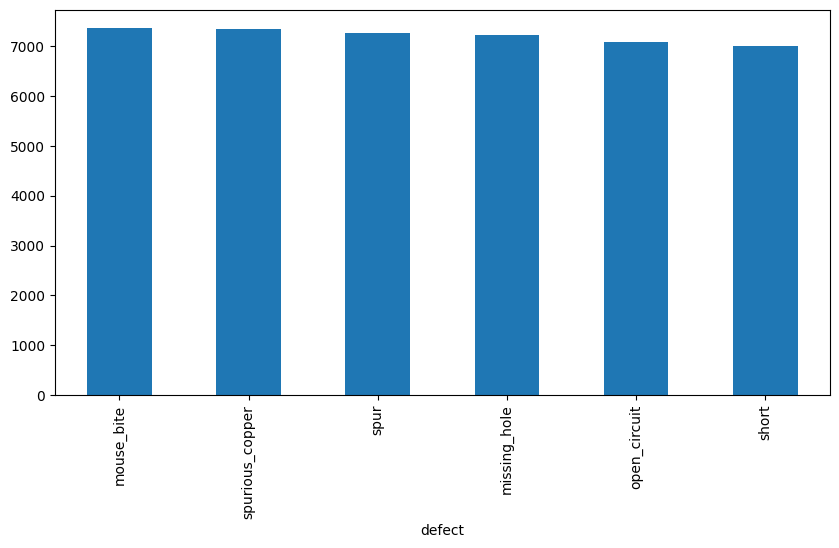

In [9]:
plt.figure(figsize=(10, 5))
df.defect.value_counts().plot(kind='bar')
plt.show()

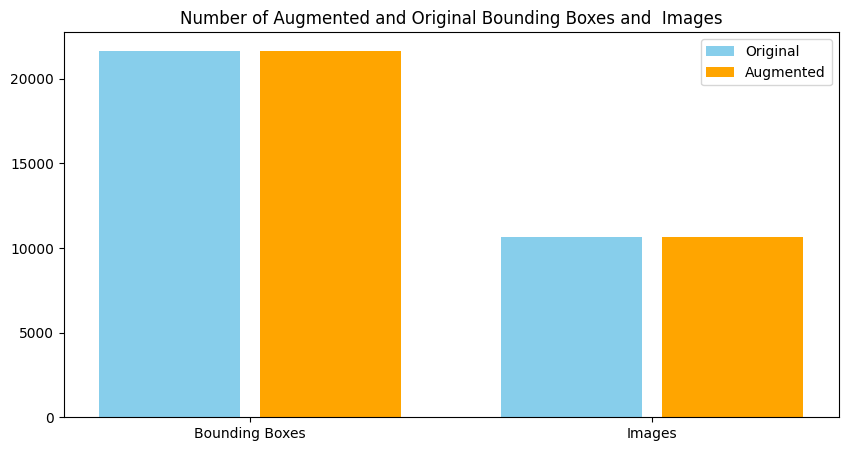

In [10]:
plt.figure(figsize=(10, 5))

x = np.arange(2)
b = [df1.shape[0], df1.filename.nunique()]
v = [df2.shape[0], df2.filename.nunique()] 
width = 0.35
  
plt.bar(x - 0.2, v, color = 'skyblue', width = width, label= 'Original')
plt.bar(x + 0.2, b, color = 'orange', width = width, label= 'Augmented')
  
plt.title("Number of Augmented and Original Bounding Boxes and  Images") 
plt.xticks(x, ['Bounding Boxes', 'Images'])
plt.legend()
plt.show() 


change to normalized bounding box:

In [50]:
df['xmin_rel'] = df.apply(lambda x: x.xmin/600, axis = 1)
df['ymin_rel'] = df.apply(lambda x: x.ymin/600, axis = 1)

#df['xmoy'] = df.apply(lambda x: (((x.xmax - x.xmin)/2)+x.xmin)/600, axis = 1 ) 
#df['ymoy'] = df.apply(lambda x: (((x.ymax - x.ymin)/2)+x.ymin)/600, axis = 1 ) 
df['w'] = df.apply(lambda x: (x.xmax - x.xmin)/600, axis = 1 )  
df['h'] = df.apply(lambda x: (x.ymax - x.ymin)/600, axis = 1 )  

df = df.drop(columns=['xmax', 'ymax', 'xmin',  'ymin'])  


One-Hot-Encoding defects:

In [51]:
df = pd.get_dummies(df, columns = ['defect'], dtype= int)


In [52]:
df.head()

,filename,xmin_rel,ymin_rel,w,h,defect_missing_hole,defect_mouse_bite,defect_open_circuit,defect_short,defect_spur,defect_spurious_copper
0,./augmented/light_06_open_circuit_05_1_600-0.jpg,0.623333,0.263333,0.030000,0.026667,0,0,1,0,0,0
1,./augmented/rotation_90_light_09_spur_02_3_600...,0.845000,0.568333,0.070000,0.041667,0,0,0,0,1,0
2,./augmented/rotation_90_light_09_spur_02_3_600...,0.330000,0.916667,0.060000,0.035000,0,0,0,0,1,0
3,./augmented/l_light_07_mouse_bite_06_4_600-3.jpg,0.006667,0.416667,0.060000,0.058333,0,1,0,0,0,0
4,./augmented/light_07_open_circuit_10_2_600-4.jpg,0.926667,0.125000,0.038333,0.035000,0,0,1,0,0,0


In [54]:

y_defect = np.array(df[['defect_missing_hole', 'defect_mouse_bite', 'defect_open_circuit', 'defect_short', 'defect_spur', 'defect_spurious_copper']], dtype='float32')

#y_bbox = np.array(df[['xmin','ymin','xmax','ymax']], dtype='float32')
#y_bbox = np.array(df[['xmoy','ymoy','w','h']], dtype='float32')
y_bbox = np.array(df[['xmin_rel','ymin_rel','w','h']], dtype='float32')

data = np.array(df['filename'])


X_tr, X_test, y_bb_tr, y_bb_test, y_d_tr, y_d_test = train_test_split(data, y_bbox, y_defect, test_size=0.2, random_state=42)

Creating a tensorflow dataset:

In [13]:
#!cat /sys/bus/pci/devices/0000\:01\:00.0/numa_node
#! sudo echo 0 | sudo tee -a /sys/bus/pci/devices/0000\:01\:00.0/numa_node


In [55]:
def transform(x, y):
    a = tf.io.read_file(x)
    a = tf.image.decode_jpeg(a)
    a = tf.image.resize(a, (224,224))
    return a, y


dataset_test = tf.data.Dataset.from_tensor_slices((X_test, {'bbox' : y_bb_test, 'defect' : y_d_test}))
dataset_test = dataset_test.map(transform)
dataset_test = dataset_test.batch(64)




In [56]:
dataset_train = tf.data.Dataset.from_tensor_slices((X_tr, {'bbox' : y_bb_tr, 'defect' : y_d_tr}))
dataset_train = dataset_train.map(transform)
dataset_train = dataset_train.batch(64)

Optimizing performance:

In [57]:
AUTOTUNE = tf.data.AUTOTUNE

dataset_train = dataset_train.prefetch(buffer_size=AUTOTUNE)
dataset_test  = dataset_test.prefetch(buffer_size=AUTOTUNE)

In [58]:
vgg16 = tf.keras.applications.VGG16(input_shape=(224, 224, 3),
                                               include_top=True,
                                               weights='imagenet')

Trainable from layer n onwards:

In [59]:
n = 0

vgg16.trainable = True

for layer in vgg16.layers[:n]:
  layer.trainable = False

In [60]:
vgg16.summary()


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

Flatten MaxPooling Layer for further processing:

In [61]:
flatten_2 = tf.keras.layers.Flatten()(vgg16.output)

Adding a Detection head:

In [62]:
x = tf.keras.layers.Dense(128, activation="relu")(flatten_2)
x = tf.keras.layers.Dense(64, activation="relu")(x)
x = tf.keras.layers.Dense(32, activation="relu")(x)
bbox_head = tf.keras.layers.Dense(4, activation="sigmoid", name = 'bbox')(x)


Adding Classification head:

In [63]:
x = tf.keras.layers.Dense(512, activation="relu")(flatten_2)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(512, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
classification_head = tf.keras.layers.Dense(6, activation="softmax", name = 'defect')(x)

Model:

In [64]:
input = vgg16.input

outputs = (bbox_head, classification_head)

model = tf.keras.Model(inputs = input,
                       outputs = outputs)



In [65]:
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer_2[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 139,274,386 (531.29 MB)

 Trainable params: 139,274,386 (531.29 MB)

 Non-trainable params: 0 (0.00 B)

Nr. of trainable layers:

In [66]:
len(model.trainable_variables)


46

In [67]:
iou = keras.metrics.OneHotIoU(num_classes=6, target_class_ids=[0])
GIoUloss = GIoULoss(bounding_box_format='rel_xyWH')  # or 'xyWH'


def regression_loss(y_true, y_pred):
    return 1/32 * (tf.math.reduce_sum(abs(y_true[:,0] - y_pred[:,0])
                                      + abs(y_true[:,1] - y_pred[:,1]) 
                                      + tf.math.square(tf.math.sqrt(abs(y_true[:,2])) - tf.math.sqrt(y_pred[:,2])) 
                                      + tf.math.square(tf.math.sqrt(abs(y_true[:,3])) - tf.math.sqrt(y_pred[:,3]))
                                      )
                   )


losses = {
	"defect": "categorical_crossentropy",
	"bbox": GIoUloss,
}

lossWeights = {
	"defect": 0.3,
	"bbox": 0.7
}

metrics = {
	"defect": "accuracy",
	"bbox": iou
}


#mAP = tf.compat.v1.metrics.average_precision_at_k()
#auc = keras.metrics.AUC()


opt = tf.keras.optimizers.Adam(learning_rate=0.0001)

In [68]:
model.compile(optimizer=opt, loss=losses, metrics=metrics)

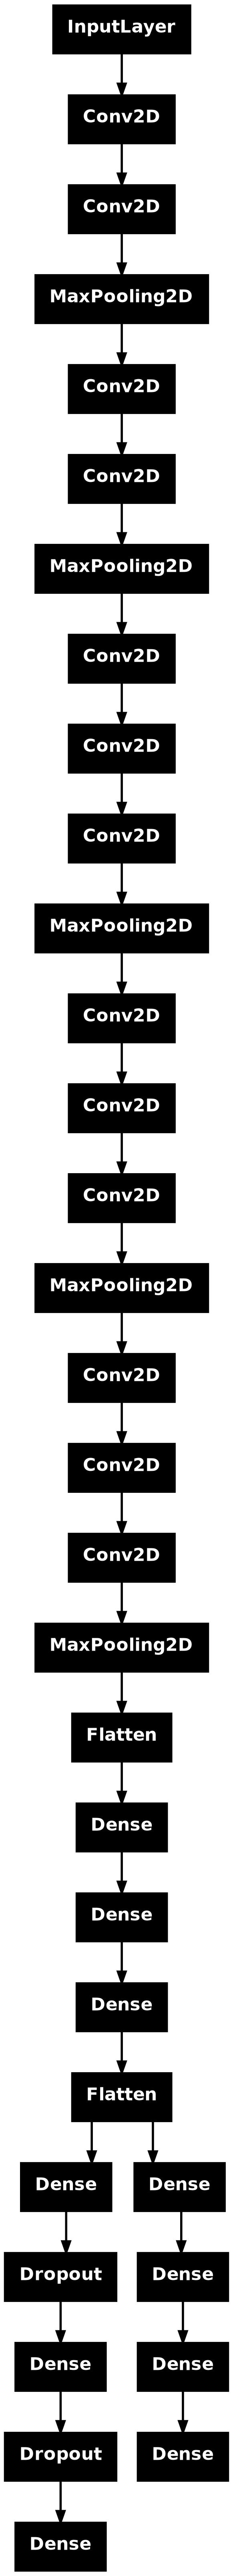

In [69]:
tf.keras.utils.plot_model(model)

Setting callbacks:

In [70]:
from tensorflow.keras import callbacks

from tf_explain.callbacks.vanilla_gradients import VanillaGradientsCallback
from tf_explain.callbacks.grad_cam import GradCAMCallback


images, labels = next(iter(dataset_test))

vanilla_grads = VanillaGradientsCallback(validation_data=(images, labels['bbox']), class_index=0, output_dir='.logs/grads')

log_dir = "./logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)



grad_cam = GradCAMCallback(validation_data=(images, labels['bbox']),
                            class_index=0,
                            output_dir='.logs/gradcam')



checkpoint = callbacks.ModelCheckpoint(filepath='.logs/ckpt/checkpoint.model.keras', 
                                       monitor='val_loss',
                                       save_best_only=True,
                                       save_weights_only=False,
                                       mode='min',
                                       save_freq='epoch')


early_stopping = callbacks.EarlyStopping(monitor='loss',
                                         patience=3,
                                         mode='min',
                                         restore_best_weights=True)

In [71]:
history = model.fit(dataset_train, epochs=3, callbacks=[early_stopping, checkpoint, tensorboard_callback], validation_data=dataset_test)


Epoch 1/3


I0000 00:00:1715671248.893795   17813 service.cc:145] XLA service 0x7ed5d80207c0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1715671248.897572   17813 service.cc:153]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1715671249.015330   17813 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 90/271 ━━━━━━━━━━━━━━━━━━━━ 27:47 9s/step - bbox_one_hot_io_u_2: 0.0379 - defect_accuracy: 0.1692 - loss: 3.0750

KeyboardInterrupt: 

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

NameError: name 'history' is not defined

In [ ]:

%load_ext tensorboard